In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import sys
sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db, tune as tu
import numpy as np
from paths.config import M2PConfig
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import plotly.express as px
from scipy.stats import ranksums, wilcoxon

In [7]:
cfg = M2PConfig()
df_exps, df_roi, df_ca, df_behave, df_behave_ca = db.get_ca_behave_data(cfg, 
                                                                        exclude_bad_behave=False, 
                                                                        exclude_bad_2p=False,
                                                                        min_ear_dist=None,
                                                                        max_ear_dist=None, #40
                                                                        calc_extra_behave=True,)

In [8]:
indexes_active = bu.get_active_indexes(df_behave)
indexes_inactive = bu.get_inactive_indexes(df_behave)

trans_indexes = bu.get_trans_indexes(df_behave)
loco_indexes = bu.get_loco_indexes(df_behave)
rot_indexes = bu.get_ahv_indexes(df_behave)

trans_only_indexes = np.logical_and(bu.get_trans_indexes(df_behave), 
                                    np.logical_not(bu.get_ahv_indexes(df_behave)))
rot_only_indexes = np.logical_and(bu.get_ahv_indexes(df_behave), 
                                  np.logical_not(bu.get_trans_indexes(df_behave)))

transrot_indexes = np.logical_and(bu.get_trans_indexes(df_behave), 
                                  bu.get_ahv_indexes(df_behave))

light_indexes = bu.get_light_indexes(df_behave)
dark_indexes = np.logical_not(light_indexes)

n_frames = indexes_active.shape[0]
n_frames_light = np.sum(light_indexes)
n_frames_dark = np.sum(dark_indexes)

print(np.sum(indexes_active) / n_frames,
      np.sum(indexes_inactive) / n_frames,
      np.sum(trans_indexes) / n_frames,
      np.sum(loco_indexes) / n_frames,
      np.sum(rot_indexes) / n_frames,
      np.sum(trans_only_indexes) / n_frames,
      np.sum(rot_only_indexes) / n_frames,
      np.sum(transrot_indexes) / n_frames,
      np.sum(light_indexes) / n_frames,
      np.sum(dark_indexes) / n_frames)

print(np.sum(np.logical_and(indexes_active, light_indexes)) / n_frames,
      np.sum(np.logical_and(indexes_inactive, light_indexes)) / n_frames,
      np.sum(np.logical_and(rot_indexes, light_indexes)) / n_frames,
      np.sum(np.logical_and(trans_indexes, light_indexes)) / n_frames,
      np.sum(np.logical_and(trans_only_indexes, light_indexes)) / n_frames,
      np.sum(np.logical_and(rot_only_indexes, light_indexes)) / n_frames,
      np.sum(np.logical_and(transrot_indexes, light_indexes)) / n_frames,
      np.sum(np.logical_and(light_indexes, light_indexes)) / n_frames,
      np.sum(np.logical_and(dark_indexes, light_indexes)) / n_frames)

print(np.sum(np.logical_and(indexes_active, dark_indexes)) / n_frames,
      np.sum(np.logical_and(indexes_inactive, dark_indexes)) / n_frames,
      np.sum(np.logical_and(rot_indexes, dark_indexes)) / n_frames,
      np.sum(np.logical_and(trans_indexes, dark_indexes)) / n_frames,
      np.sum(np.logical_and(rot_only_indexes, dark_indexes)) / n_frames,
      np.sum(np.logical_and(trans_only_indexes, dark_indexes)) / n_frames,
      np.sum(np.logical_and(transrot_indexes, dark_indexes)) / n_frames,
      np.sum(np.logical_and(light_indexes, dark_indexes)) / n_frames,
      np.sum(np.logical_and(dark_indexes, dark_indexes)) / n_frames)


0.8361728261819228 0.16382717381807715 0.6719858976137981 0.38313366944705696 0.6153656393098876 0.09016481906905749 0.03354456076514696 0.5818210785447406 0.4876167275680065 0.5123832724319936
0.41483320227981724 0.07278352528818925 0.3107612924446363 0.34237345626667076 0.04623362473468087 0.014621460912646407 0.2961398315319899 0.4876167275680065 0.0
0.4213396239021056 0.09104364852988792 0.3046043468652513 0.32961244134712736 0.01892309985250055 0.04393119433437662 0.2856812470127507 0.0 0.5123832724319936


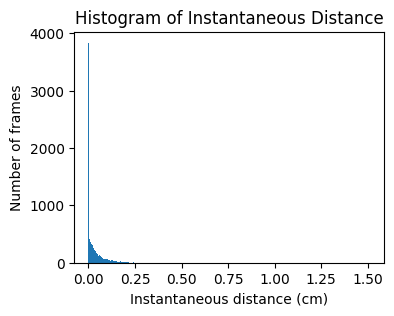

In [10]:
# Plot a histogram of df_behave[bu.DIST_INST_CM]
fig, ax = plt.subplots(figsize=(4,3))
# Filter to when active
active_mask = df_behave[bu.IS_ACTIVE] == 1
ax.hist(df_behave[bu.DIST_FILT_CM][active_mask], bins=10000)
ax.set_xlabel('Instantaneous distance (cm)')
ax.set_ylabel('Number of frames')
ax.set_title('Histogram of Instantaneous Distance')
# plt.xlim(0, 0.1)
# plt.ylim(0, 2000)
plt.show()